In [5]:
!pip install tensorflow keras kaggle matplotlib seaborn scikit-learn


In [6]:
from google.colab import files
files.upload()  # choose kaggle.json from your computer

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"luvinson","key":"3b1e057247978405adc96a758f96a806"}'}

In [7]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [8]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p ./data --unzip


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 77% 115M/149M [00:00<00:00, 1.20GB/s]
100% 149M/149M [00:00<00:00, 1.06GB/s]


In [9]:
import os

train_dir = "./data/Training"
test_dir = "./data/Testing"

print("Training classes:", os.listdir(train_dir))
print("Testing classes:", os.listdir(test_dir))

Training classes: ['meningioma', 'notumor', 'pituitary', 'glioma']
Testing classes: ['meningioma', 'notumor', 'pituitary', 'glioma']


In [11]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 16

# Data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15
)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Model
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers[:200]:
    layer.trainable = False
for layer in base_model.layers[200:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Training
history = model.fit(train_gen,
                    validation_data=val_gen,
                    epochs=5)


Found 4857 images belonging to 4 classes.
Found 855 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Epoch 1/5
304/304 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.6644 - loss: 0.8224 - val_accuracy: 0.8632 - val_loss: 0.3772
Epoch 2/5
304/304 ━━━━━━━━━━━━━━━━━━━━ 468s 2s/step - accuracy: 0.9070 - loss: 0.2556 - val_accuracy: 0.8865 - val_loss: 0.3015
Epoch 3/5
304/304 ━━━━━━━━━━━━━━━━━━━━ 494s 2s/step - accuracy: 0.9368 - loss: 0.1811 - val_accuracy: 0.9298 - val_loss: 0.2111
Epoch 4/5
304/304 ━━━━━━━━━━━━━━━━━━━━ 446s 1s/step - accuracy: 0.9562 - loss: 0.1249 - val_accuracy: 0.9427 - val_loss: 0.1756
Epoch 5/5
304/304 ━━━━━━━━━━━━━━━━━━━━ 451s 1s/step - accuracy: 0.9619 - loss: 0.1018 - val_accuracy: 0.9497 - val_loss: 0.1490


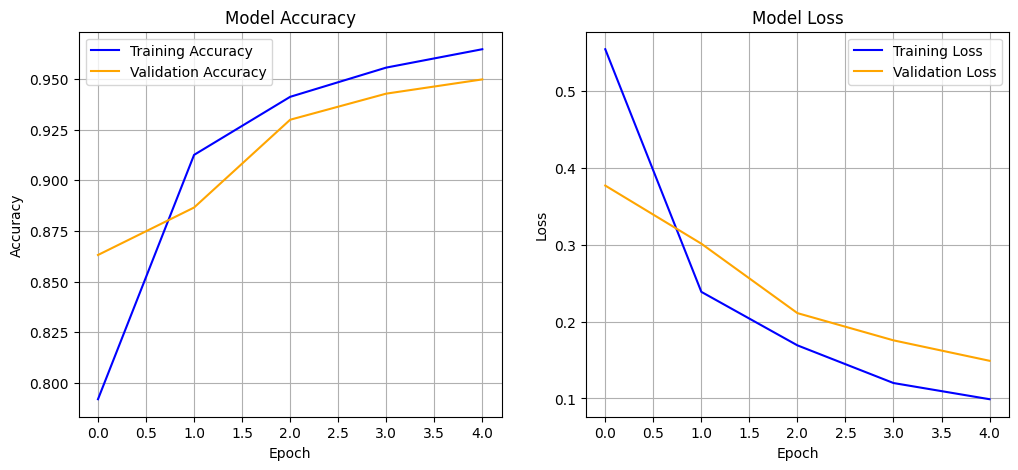

In [12]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()


In [14]:
model.save("efficientnet_brain_tumor_model.h5")



In [15]:
from google.colab import files
files.download("efficientnet_brain_tumor_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>